# Notebook 05: Model Evaluation

**Purpose:** Apply both trained models to the held-out test set, compute all evaluation metrics, generate comparison charts, and select the winning model.

**CRITICAL RULE:** The test set is used EXACTLY ONCE — here. It was never touched during training or hyperparameter tuning (CV used only the training set). Using the test set for any tuning decisions would constitute data leakage.

## Why Each Metric

| Metric | Audience | Formula | Threshold |
|--------|---------|---------|----------|
| AUC-ROC | Data Scientist | Area under ROC curve | >0.70 acceptable, >0.80 excellent |
| Gini | Banking/Business | 2×AUC - 1 | >0.40 for acceptable scorecard |
| PR-AUC | Data Scientist (imbalanced) | Area under Precision-Recall curve | Baseline = default rate |
| KS Statistic | Credit scoring | Max separation between defaulter/non-defaulter CDFs | >0.40 is good |
| Recall | Risk management | TP/(TP+FN) | Maximise — don't miss defaults |
| Business Cost | Business stakeholder | (FN×4) + (FP×1) | Minimise |

**Why accuracy is NOT in this table:** With ~15% default rate, accuracy of a model that always predicts 'no default' = 85%. It catches zero defaults. Accuracy is useless for imbalanced credit data.

In [1]:
# ── CELL 1: Environment setup ──────────────────────────────────────────────────
import sys, os, json

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)
from scipy.stats import ks_2samp
from preprocessing import TARGET

PROCESSED    = f'{BASE_PATH}/data/processed'
MODELS_PATH  = f'{BASE_PATH}/models'
FIGURES_PATH = f'{BASE_PATH}/reports/figures'
print('Environment ready.')

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit
Environment ready.


In [2]:
# ── CELL 2: Load test data and all trained models ─────────────────────────────
import numpy as np
X_test = pd.read_csv(f'{PROCESSED}/X_test.csv', index_col=0)
y_test = pd.read_csv(f'{PROCESSED}/y_test.csv', index_col=0).squeeze('columns')

X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

best_lr   = joblib.load(f'{MODELS_PATH}/logistic_regression_v1.pkl')
best_xgb  = joblib.load(f'{MODELS_PATH}/xgboost_v1.pkl')

try:
    best_lgbm = joblib.load(f'{MODELS_PATH}/lightgbm_v1.pkl')
    LGBM_AVAILABLE = True
    print('LightGBM model loaded.')
except FileNotFoundError:
    best_lgbm = None
    LGBM_AVAILABLE = False
    print('lightgbm_v1.pkl not found — skipping LGBM evaluation.')

try:
    stacking_model = joblib.load(f'{MODELS_PATH}/stacking_v1.pkl')
    STACKING_AVAILABLE = True
    print('Stacking ensemble loaded.')
except FileNotFoundError:
    stacking_model = None
    STACKING_AVAILABLE = False
    print('stacking_v1.pkl not found — skipping stacking evaluation.')

print(f'\nTest set: {X_test.shape[0]:,} rows')
print(f'Default rate in test: {y_test.mean():.2%}')
print('Models loaded.')


LightGBM model loaded.
Stacking ensemble loaded.

Test set: 608 rows
Default rate in test: 13.32%
Models loaded.


In [3]:
# ── CELL 3: Comprehensive evaluation function ─────────────────────────────────
def comprehensive_evaluation(model, X_test, y_test, model_name):
    """
    Compute the full evaluation suite for a credit scoring model.
    Returns a dict of metrics and arrays for plotting.
    """
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of default
    y_pred = (y_prob >= 0.5).astype(int)          # at default 0.5 threshold

    # ── Core metrics ──────────────────────────────────────────────────────────
    auc_roc = roc_auc_score(y_test, y_prob)
    gini    = 2 * auc_roc - 1
    pr_auc  = average_precision_score(y_test, y_prob)

    # ── KS Statistic ──────────────────────────────────────────────────────────
    # KS = maximum separation between defaulter and non-defaulter score CDFs
    # Used in retail banking as a standard scorecard discrimination metric.
    # KS > 0.40 = good scorecard
    pos_scores = y_prob[y_test == 1]   # scores for actual defaulters
    neg_scores = y_prob[y_test == 0]   # scores for non-defaulters
    ks_stat, ks_pval = ks_2samp(pos_scores, neg_scores)

    # ── Standard classification metrics at 0.5 threshold ─────────────────────
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall_05    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_05 = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_05        = f1_score(y_test, y_pred, zero_division=0)

    # ── Threshold sweep ───────────────────────────────────────────────────────
    # WHY sweep thresholds:
    # 0.5 is an arbitrary default. For credit risk, we will use a different
    # threshold in the Decision Engine. This sweep shows how all metrics
    # change across thresholds — the business chooses based on cost tradeoff.
    thresholds = np.arange(0.05, 0.95, 0.01)
    thresh_results = []
    for t in thresholds:
        y_t = (y_prob >= t).astype(int)
        cm_t = confusion_matrix(y_test, y_t)
        if cm_t.shape == (2, 2):
            tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
            # Business cost: missed default (FN) costs 4x foregone interest (FP)
            # Based on: GHS 80K loss on default vs GHS 22K foregone interest at 22%
            business_cost = (fn_t * 4) + (fp_t * 1)
            thresh_results.append({
                'threshold':     t,
                'recall':        tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0,
                'precision':     tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0,
                'f1':            f1_score(y_test, y_t, zero_division=0),
                'business_cost': business_cost,
                'fn': fn_t, 'fp': fp_t, 'tp': tp_t, 'tn': tn_t
            })

    thresh_df = pd.DataFrame(thresh_results)
    optimal_thresh = thresh_df.loc[thresh_df['business_cost'].idxmin(), 'threshold']

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f'\n{"="*55}')
    print(f'MODEL: {model_name}')
    print(f'{"="*55}')
    print(f'AUC-ROC              : {auc_roc:.4f}')
    print(f'Gini Coefficient     : {gini:.4f}  (industry standard: >0.40 = acceptable)')
    print(f'PR-AUC               : {pr_auc:.4f}  (baseline = {y_test.mean():.4f})')
    print(f'KS Statistic         : {ks_stat:.4f}  (>0.40 = good)')
    print(f'Recall @ 0.5         : {recall_05:.4f}')
    print(f'Precision @ 0.5      : {precision_05:.4f}')
    print(f'F1 @ 0.5             : {f1_05:.4f}')
    print(f'Optimal threshold    : {optimal_thresh:.2f}  (minimises business cost)')

    return {
        'model_name':     model_name,
        'auc_roc':        auc_roc,
        'gini':           gini,
        'pr_auc':         pr_auc,
        'ks_stat':        ks_stat,
        'recall_05':      recall_05,
        'precision_05':   precision_05,
        'f1_05':          f1_05,
        'optimal_thresh': optimal_thresh,
        'y_prob':         y_prob,
        'thresh_df':      thresh_df,
        'confusion_matrix': cm,
        'pos_scores':     pos_scores,
        'neg_scores':     neg_scores,
    }

print('Evaluation function defined.')

Evaluation function defined.


In [4]:
# ── CELL 4: Evaluate all models on test set ───────────────────────────────────
all_results = {}

lr_results  = comprehensive_evaluation(best_lr,  X_test, y_test, 'Logistic Regression')
all_results['LR'] = lr_results

xgb_results = comprehensive_evaluation(best_xgb, X_test, y_test, 'XGBoost')
all_results['XGB'] = xgb_results

if LGBM_AVAILABLE and best_lgbm:
    lgbm_results = comprehensive_evaluation(best_lgbm, X_test, y_test, 'LightGBM')
    all_results['LGBM'] = lgbm_results

if STACKING_AVAILABLE and stacking_model:
    stack_results = comprehensive_evaluation(stacking_model, X_test, y_test, 'Stacking Ensemble')
    all_results['Stacking'] = stack_results



MODEL: Logistic Regression
AUC-ROC              : 0.5800
Gini Coefficient     : 0.1600  (industry standard: >0.40 = acceptable)
PR-AUC               : 0.1814  (baseline = 0.1332)
KS Statistic         : 0.1582  (>0.40 = good)
Recall @ 0.5         : 0.4691
Precision @ 0.5      : 0.1681
F1 @ 0.5             : 0.2476
Optimal threshold    : 0.75  (minimises business cost)

MODEL: XGBoost
AUC-ROC              : 0.5343
Gini Coefficient     : 0.0687  (industry standard: >0.40 = acceptable)
PR-AUC               : 0.1463  (baseline = 0.1332)
KS Statistic         : 0.1116  (>0.40 = good)
Recall @ 0.5         : 0.2346
Precision @ 0.5      : 0.1450
F1 @ 0.5             : 0.1792
Optimal threshold    : 0.85  (minimises business cost)

MODEL: LightGBM
AUC-ROC              : 0.5749
Gini Coefficient     : 0.1497  (industry standard: >0.40 = acceptable)
PR-AUC               : 0.1677  (baseline = 0.1332)
KS Statistic         : 0.1383  (>0.40 = good)
Recall @ 0.5         : 0.2593
Precision @ 0.5      : 0.

In [5]:
# ── CELL 5: Summary comparison table (all models) ─────────────────────────────
metrics = ['AUC-ROC', 'Gini', 'PR-AUC', 'KS Statistic', 'Recall @ 0.5']
metric_keys = ['auc_roc', 'gini', 'pr_auc', 'ks_stat', 'recall_05']

rows = []
for metric_label, metric_key in zip(metrics, metric_keys):
    row = {'Metric': metric_label}
    for model_name, res in all_results.items():
        row[model_name] = f"{res[metric_key]:.4f}"
    # Mark best
    best_val = max(all_results[m][metric_key] for m in all_results)
    best_model = [m for m in all_results if all_results[m][metric_key] == best_val][0]
    row['Best'] = best_model
    rows.append(row)

summary = pd.DataFrame(rows)
print('MODEL COMPARISON ON HELD-OUT TEST SET')
print(summary.to_string(index=False))


MODEL COMPARISON ON HELD-OUT TEST SET
      Metric     LR    XGB   LGBM Stacking Best
     AUC-ROC 0.5800 0.5343 0.5749   0.5736   LR
        Gini 0.1600 0.0687 0.1497   0.1472   LR
      PR-AUC 0.1814 0.1463 0.1677   0.1702   LR
KS Statistic 0.1582 0.1116 0.1383   0.1288   LR
Recall @ 0.5 0.4691 0.2346 0.2593   0.0000   LR


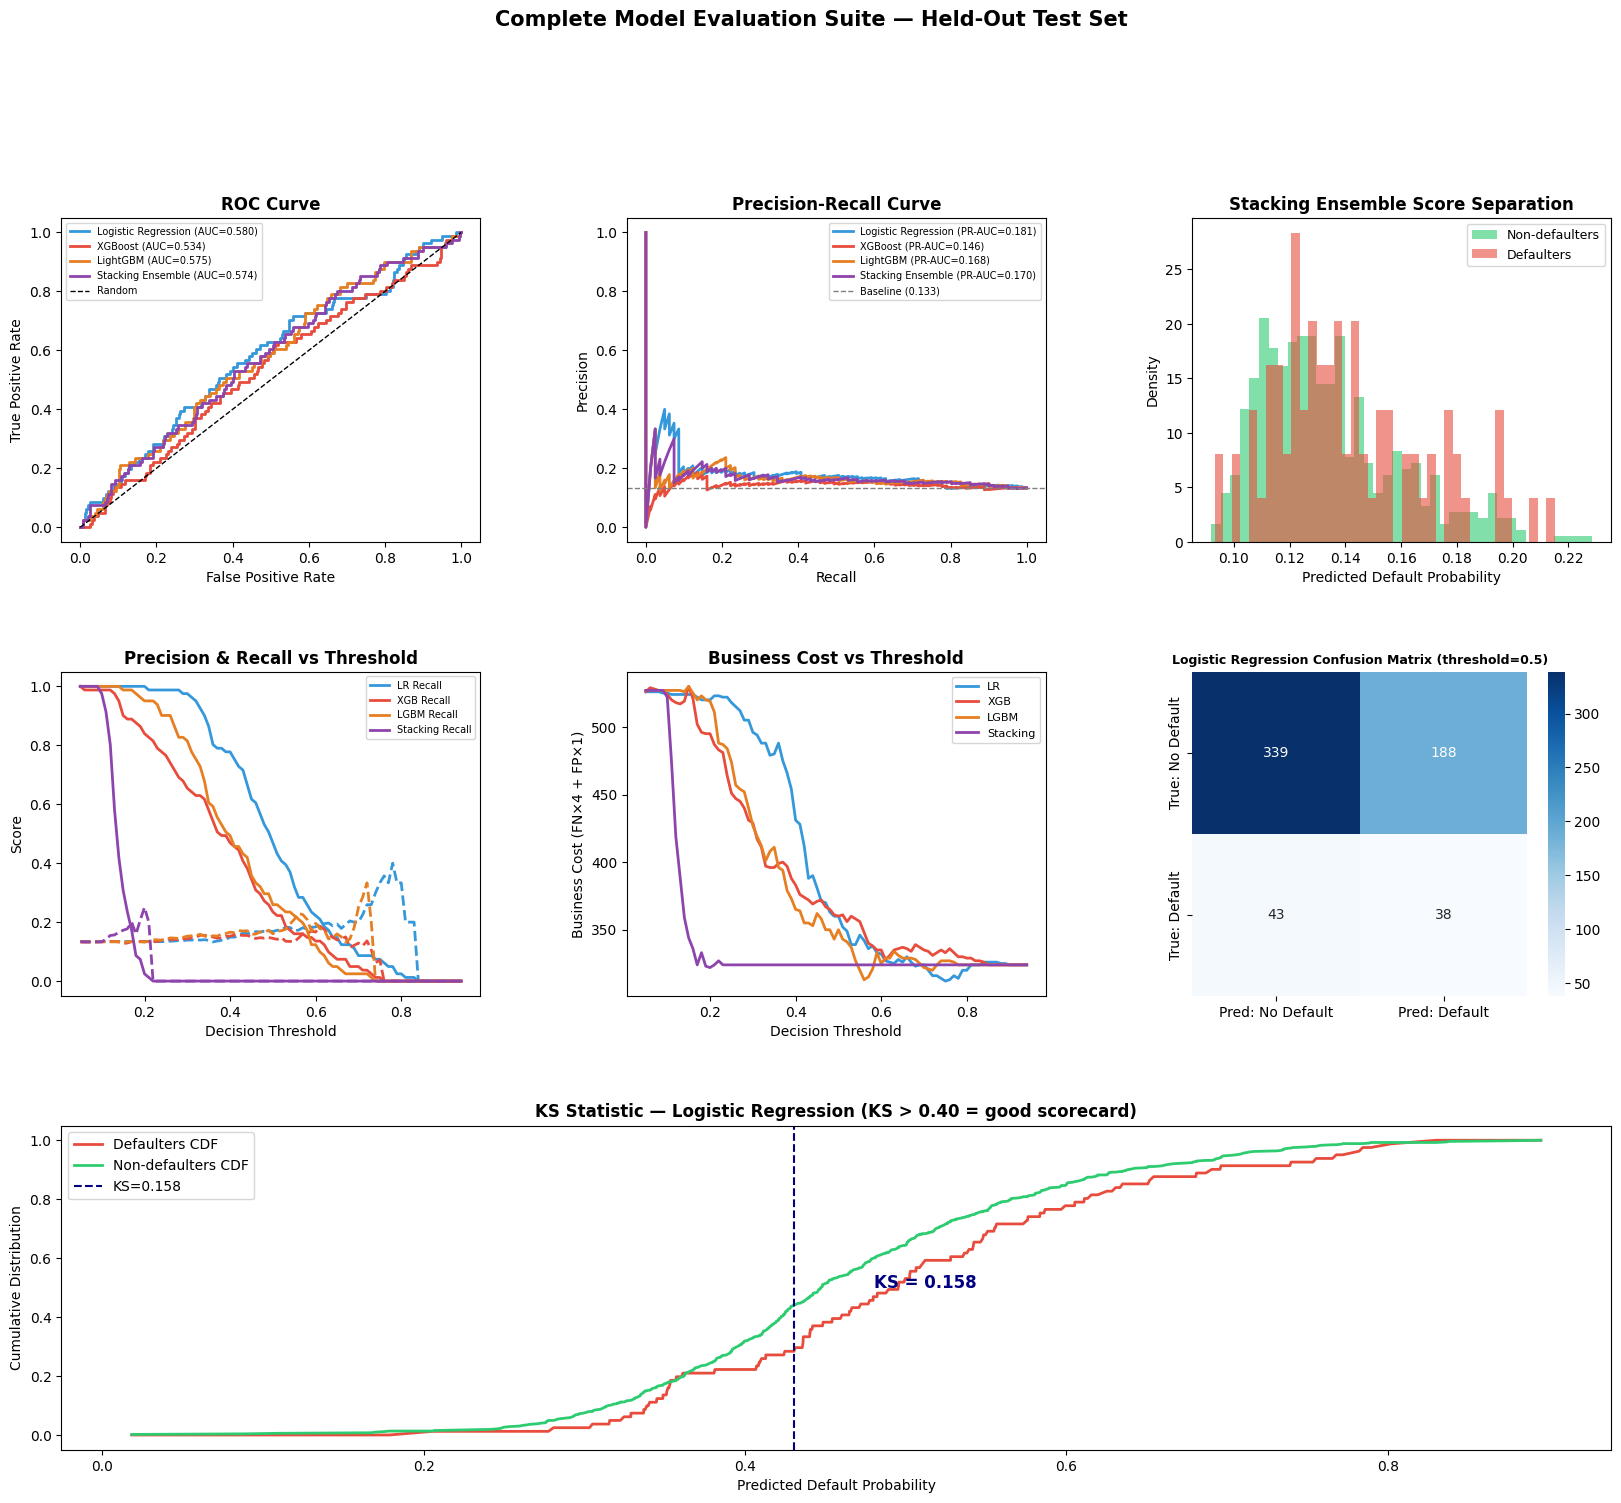

Saved: 12_complete_evaluation.png


In [6]:
# ── CELL 6: Evaluation chart suite ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

COLORS = {
    'Logistic Regression': '#3498db',
    'XGBoost':             '#e74c3c',
    'LightGBM':            '#e67e22',
    'Stacking Ensemble':   '#8e44ad',
}

# ── Plot 1: ROC Curves ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for res in all_results.values():
    c = COLORS.get(res['model_name'], '#333')
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, color=c, lw=2,
             label=f"{res['model_name']} (AUC={res['auc_roc']:.3f})")
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold'); ax1.legend(fontsize=7)

# ── Plot 2: Precision-Recall Curves ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for res in all_results.values():
    c = COLORS.get(res['model_name'], '#333')
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(rec, prec, color=c, lw=2,
             label=f"{res['model_name']} (PR-AUC={res['pr_auc']:.3f})")
ax2.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
            label=f'Baseline ({y_test.mean():.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold'); ax2.legend(fontsize=7)

# ── Plot 3: Score distribution for best tree model ────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
best_tree_key = 'Stacking' if 'Stacking' in all_results else ('LGBM' if 'LGBM' in all_results else 'XGB')
best_tree = all_results[best_tree_key]
ax3.hist(best_tree['neg_scores'], bins=40, alpha=0.6, color='#2ecc71',
         label='Non-defaulters', density=True)
ax3.hist(best_tree['pos_scores'], bins=40, alpha=0.6, color='#e74c3c',
         label='Defaulters', density=True)
ax3.set_xlabel('Predicted Default Probability'); ax3.set_ylabel('Density')
ax3.set_title(f'{best_tree["model_name"]} Score Separation', fontweight='bold')
ax3.legend(fontsize=9)

# ── Plot 4: Threshold sweep — best model ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for key, res in all_results.items():
    c = COLORS.get(res['model_name'], '#333')
    tdf = res['thresh_df']
    ax4.plot(tdf['threshold'], tdf['recall'],    color=c, lw=2, label=f'{key} Recall')
    ax4.plot(tdf['threshold'], tdf['precision'], color=c, lw=2, linestyle='--')
ax4.set_xlabel('Decision Threshold'); ax4.set_ylabel('Score')
ax4.set_title('Precision & Recall vs Threshold', fontweight='bold'); ax4.legend(fontsize=7)

# ── Plot 5: Business cost vs threshold ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for key, res in all_results.items():
    c = COLORS.get(res['model_name'], '#333')
    tdf = res['thresh_df']
    ax5.plot(tdf['threshold'], tdf['business_cost'], color=c, lw=2, label=key)
ax5.set_xlabel('Decision Threshold'); ax5.set_ylabel('Business Cost (FN×4 + FP×1)')
ax5.set_title('Business Cost vs Threshold', fontweight='bold'); ax5.legend(fontsize=8)

# ── Plot 6: Confusion matrix for best model ───────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
best_key = max(all_results, key=lambda k: all_results[k]['auc_roc'])
cm_best = all_results[best_key]['confusion_matrix']
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['True: No Default', 'True: Default'])
ax6.set_title(f'{all_results[best_key]["model_name"]} Confusion Matrix (threshold=0.5)',
              fontweight='bold', fontsize=9)

# ── Plot 7: KS statistic for best model ──────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
best_res = all_results[best_key]
scores_sorted = np.sort(np.unique(best_res['y_prob']))
cdf_pos = [(best_res['pos_scores'] <= s).mean() for s in scores_sorted]
cdf_neg = [(best_res['neg_scores'] <= s).mean() for s in scores_sorted]
ax7.plot(scores_sorted, cdf_pos, color='#e74c3c', lw=2, label='Defaulters CDF')
ax7.plot(scores_sorted, cdf_neg, color='#2ecc71', lw=2, label='Non-defaulters CDF')
ks_idx = np.argmax(np.abs(np.array(cdf_pos) - np.array(cdf_neg)))
ks_x   = scores_sorted[ks_idx]
ax7.axvline(ks_x, color='navy', linestyle='--', lw=1.5,
            label=f'KS={best_res["ks_stat"]:.3f}')
ax7.annotate(f'KS = {best_res["ks_stat"]:.3f}',
             xy=(ks_x, 0.5), xytext=(ks_x + 0.05, 0.5),
             fontsize=12, fontweight='bold', color='navy')
ax7.set_xlabel('Predicted Default Probability'); ax7.set_ylabel('Cumulative Distribution')
ax7.set_title(f'KS Statistic — {best_res["model_name"]} (KS > 0.40 = good scorecard)',
              fontweight='bold')
ax7.legend()

plt.suptitle('Complete Model Evaluation Suite — Held-Out Test Set',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{FIGURES_PATH}/12_complete_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_complete_evaluation.png')


In [7]:
# ── CELL 7: Model selection decision ──────────────────────────────────────────
print('MODEL SELECTION DECISION')
print('=' * 55)

# Rank by test set AUC
ranked = sorted(all_results.items(), key=lambda kv: -kv[1]['auc_roc'])
print('Test set AUC ranking:')
for name, res in ranked:
    print(f'  {name:<20} AUC={res["auc_roc"]:.4f}  Gini={res["gini"]:.4f}  Optimal_thresh={res["optimal_thresh"]:.2f}')

print()
best_test_key, best_test_res = ranked[0]
lr_test_auc = all_results['LR']['auc_roc']
delta_vs_lr = best_test_res['auc_roc'] - lr_test_auc

# MODEL SELECTION RULE:
# Prefer more complex model only if it improves AUC by > 0.02 on the TEST set.
# This threshold is set by regulatory preference for interpretability
# (Basel II/III credit model guidelines).
if delta_vs_lr > 0.02 or best_test_key == 'LR':
    WINNING_MODEL = best_test_key
    winning_pipeline = all_results[best_test_key]
    print(f'SELECTED: {best_test_key}')
    if best_test_key == 'LR':
        print('Reason: Logistic Regression has best test AUC or no model beats it by >0.02.')
        print('        LR is preferred for regulatory interpretability.')
    else:
        print(f'Reason: {best_test_key} beats LR by {delta_vs_lr:+.4f} AUC on test set (> 0.02 threshold).')
else:
    WINNING_MODEL = 'LR'
    winning_pipeline = all_results['LR']
    print('SELECTED: Logistic Regression')
    print(f'Reason: Best model ({best_test_key}) beats LR by only {delta_vs_lr:+.4f} AUC.')
    print('        AUC improvement < 0.02 does not justify added complexity.')

# Map to file name
_name_to_file = {
    'LR':       'logistic_regression_v1',
    'XGB':      'xgboost_v1',
    'LGBM':     'lightgbm_v1',
    'Stacking': 'stacking_v1',
}
winning_model_file = _name_to_file.get(WINNING_MODEL, 'logistic_regression_v1')
winning_results = all_results[WINNING_MODEL]

print()
print(f'Winning model AUC-ROC : {winning_results["auc_roc"]:.4f}')
print(f'Winning model Gini    : {winning_results["gini"]:.4f}')
print(f'Optimal threshold     : {winning_results["optimal_thresh"]:.2f}')

# Update model registry
with open(f'{MODELS_PATH}/model_registry.json') as f:
    registry = json.load(f)
registry['winning_model']     = winning_model_file
registry['winning_model_auc'] = winning_results['auc_roc']
registry['winning_model_gini'] = winning_results['gini']
registry['optimal_threshold'] = float(winning_results['optimal_thresh'])
# Store test AUC for all models
for key, res in all_results.items():
    file_key = _name_to_file.get(key, key.lower())
    if file_key in registry:
        registry[file_key]['test_auc']  = round(res['auc_roc'], 4)
        registry[file_key]['test_gini'] = round(res['gini'], 4)
with open(f'{MODELS_PATH}/model_registry.json', 'w') as f:
    json.dump(registry, f, indent=2)

# Save winning model probabilities on test set
y_prob_test = winning_results['y_prob']
pd.Series(y_prob_test, index=X_test.index, name='default_probability').to_csv(
    f'{PROCESSED}/y_prob_test.csv'
)
print(f'\nSaved test set probabilities to: {PROCESSED}/y_prob_test.csv')
print(f'Winning model file: {winning_model_file}')
print('Proceed to notebook 06_decision_engine.ipynb')


MODEL SELECTION DECISION
Test set AUC ranking:
  LR                   AUC=0.5800  Gini=0.1600  Optimal_thresh=0.75
  LGBM                 AUC=0.5749  Gini=0.1497  Optimal_thresh=0.56
  Stacking             AUC=0.5736  Gini=0.1472  Optimal_thresh=0.20
  XGB                  AUC=0.5343  Gini=0.0687  Optimal_thresh=0.85

SELECTED: LR
Reason: Logistic Regression has best test AUC or no model beats it by >0.02.
        LR is preferred for regulatory interpretability.

Winning model AUC-ROC : 0.5800
Winning model Gini    : 0.1600
Optimal threshold     : 0.75

Saved test set probabilities to: /content/drive/MyDrive/stanbic_sme_credit/data/processed/y_prob_test.csv
Winning model file: logistic_regression_v1
Proceed to notebook 06_decision_engine.ipynb
